In [1]:
library(patchwork)
library(readr)
library(stringr)
library(dplyr)
set.seed(1234)

#### Send to channel code
library(parallel)
library(ggpubr)
library(qvalue)

library(pheatmap)
library(RColorBrewer)
library(beeswarm)
library(lme4)
library(lmerTest)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [2]:
in_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'

#Load in devscores, info, motif
motifdata <- read.table(file=paste0(in_dir,'motifdata.txt'), sep="\t")
info <- read.table(file=paste0(in_dir,'info_table.txt'))
TFClass_Lookup <- read_csv("/nfs/lab/welison/References/220907_WE_Chromvar_to_Gene_By_Subfam_Complete(JAPRAR2022_TFClass).csv")
TFClass_Full <- read_csv("/nfs/lab/welison/References/220907_WE_Chromvar_to_Gene_Jaspar2022.csv")
variability <- read.table(file=paste0(in_dir,'variability.txt'), sep="\t")

head(motifdata)
head(info)
dim(TFClass_Lookup)
head(TFClass_Lookup)

head(variability)
dim(variability)

Rows: 10368 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): full_jaspar_motif, jaspar_motif, lowest_level_family, gene

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1669 Columns: 20
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (20): full_jaspar_motif, jaspar_motif, jaspar_name_1, jaspar_name_2, TFC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


,V1,V2,V3
,<chr>,<chr>,<chr>
1,MA0030.1_FOXF2,FOXF2,Fork head/winged helix factors
2,MA0031.1_FOXD1,FOXD1,Fork head/winged helix factors
3,MA0051.1_IRF2,IRF2,Tryptophan cluster factors
4,MA0059.1_MAX::MYC,MAX::MYC,Basic helix-loop-helix factors (bHLH)
5,MA0066.1_PPARG,PPARG,Nuclear receptors with C4 zinc fingers
6,MA0069.1_PAX6,PAX6,Paired box factors


,def,cells,groups,cluster,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
MM_339_AAACGAATCCCGAAGC-1,MM_339,MM_339_AAACGAATCCCGAAGC-1,earlyT1D,Acinar_1_2_6,6247,0.5421319,4.928013,748,715
MM_339_AAACGAATCTATGAGC-1,MM_339,MM_339_AAACGAATCTATGAGC-1,earlyT1D,Acinar_1_2_6,6247,0.7366399,5.622038,830,802
MM_339_AAACTCGGTGTGCTTA-1,MM_339,MM_339_AAACTCGGTGTGCTTA-1,earlyT1D,Acinar_1_2_6,6247,0.6134342,4.720066,505,489
MM_339_AAAGATGTCGGATGTT-1,MM_339,MM_339_AAAGATGTCGGATGTT-1,earlyT1D,Acinar_1_2_6,6247,0.6927803,4.036170,746,726
MM_339_AAAGGATAGGAGTCTG-1,MM_339,MM_339_AAAGGATAGGAGTCTG-1,earlyT1D,Acinar_1_2_6,6247,0.7235805,5.164169,621,602
MM_339_AAAGGATAGTCGAGCA-1,MM_339,MM_339_AAAGGATAGTCGAGCA-1,earlyT1D,Acinar_1_2_6,6247,0.5906291,4.659066,834,797


[1] 10368     4

full_jaspar_motif,jaspar_motif,lowest_level_family,gene
<chr>,<chr>,<chr>,<chr>
MA0030.1_FOXF2,FOXF2,FOXF,FOXF2
MA0030.1_FOXF2,FOXF2,FOXF,FOXF1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD2
MA0031.1_FOXD1,FOXD1,FOXD,FOXD3
MA0031.1_FOXD1,FOXD1,FOXD,FOXD4L1


,name,variability,bootstrap_lower_bound,bootstrap_upper_bound,p_value,p_value_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,FOXF2,1.203838,1.198981,1.208643,0.000000e+00,0.000000e+00
MA0031.1_FOXD1,FOXD1,1.258115,1.252999,1.263342,0.000000e+00,0.000000e+00
MA0051.1_IRF2,IRF2,1.113662,1.108953,1.118249,0.000000e+00,0.000000e+00
MA0059.1_MAX::MYC,MAX::MYC,1.035252,1.031647,1.038709,1.326763e-95,1.932884e-95
MA0066.1_PPARG,PPARG,1.018128,1.014559,1.021752,6.234495e-27,7.676638e-27
MA0069.1_PAX6,PAX6,1.054041,1.049918,1.058356,2.990752e-220,5.306667e-220


[1] 692   6

In [3]:
# Load in sample level information 
wd_meta='/nfs/lab/rlmelton/npod/notebooks/sherlock/Downstream_analysis_nPOD_april2022/DESEQ_rna/'
meta.data =read.csv(paste0(wd_meta,'nPOD_clinical_July2022_nPOD_metadata_august2022_snATAC.csv'))
disease = meta.data[,c("SeqID_ATAC","Condition_subtype","Age","Sex","BMI","TSSe")]

# Merge sample and barcode level covariates
disease.meta <- left_join(select(info, SeqID_ATAC=def, groups, samples), disease)
disease.meta <- select(disease.meta, -SeqID_ATAC, -Condition_subtype, -TSSe)
disease.meta <- disease.meta[!duplicated(disease.meta),]

dim(disease.meta)
head(disease.meta)

Joining with `by = join_by(SeqID_ATAC)`


[1] 29  5

,groups,samples,Age,Sex,BMI
,<chr>,<int>,<dbl>,<chr>,<dbl>
1,earlyT1D,6247,24.00,Male,24.27
574,lateT1D,6418,24.86,Male,26.40
953,ND,6339,23.30,Male,25.00
1129,Aab,6197,22.00,Male,28.20
1522,earlyT1D,6380,11.60,Female,14.60
1697,ND,6375,28.70,Male,31.80


In [4]:
# This is the big one; the deviation scores. Runs slow
dev_file <- paste0(in_dir,'devscores.txt')

devscores <- vroom::vroom(file=dev_file, skip=1, col_names=FALSE)
devscores <- tibble::column_to_rownames(devscores, var="X1")
colnames(devscores) <- str_split(readLines(file(dev_file),n=1), " ")[[1]]

dim(devscores)
head(devscores)

Rows: 692 Columns: 174599
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr      (1): X1
dbl (174598): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1]    692 174598

,MM_339_AAACGAATCCCGAAGC-1,MM_339_AAACGAATCTATGAGC-1,MM_339_AAACTCGGTGTGCTTA-1,MM_339_AAAGATGTCGGATGTT-1,MM_339_AAAGGATAGGAGTCTG-1,MM_339_AAAGGATAGTCGAGCA-1,MM_339_AAAGGGCCAGTCAGCC-1,MM_339_AAAGGGCTCGATATGC-1,MM_339_AAAGGGCTCGGTTAGT-1,MM_339_AAATGAGGTGCCAAGA-1,⋯,MM_391_GTGCCAGCAGGGTAAC-1,MM_460_AAATGCCGTGCATTGT-1,MM_460_GCACCTTCATGCGCTG-1,MM_460_GTAATCGCAAAGAAGG-1,MM_460_TAGTCCCAGAAAGCAG-1,MM_460_TTCATTGTCGCAAACT-1,MM_536_GGAGGATCATCCCTCA-1,MM_544_CTAGCGGGTTTAGACC-1,MM_546_GCACGGTCAGTCAGCC-1,MM_546_TTGCAGAGTTCTGAGT-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,0.54520151,0.40990183,3.35607428,2.000801239,0.9658235,-0.459021816,0.44334913,-0.25558497,-1.6471011,0.8835954,⋯,-1.3485672,-1.24054617,0.6432168,0.53422671,-0.8512291,0.34641291,-1.3156336,-0.1606987,-0.4841276,-0.1220044
MA0031.1_FOXD1,-0.64639620,0.56733851,2.16471443,0.222432873,0.1040411,-1.840425687,1.07262678,-0.05391174,1.3205662,0.8736271,⋯,-2.0031346,-1.47942813,-0.2572786,-0.84672181,-1.4112522,-1.44849245,-1.0407649,-0.3555410,-2.0004751,-1.9848008
MA0051.1_IRF2,-0.04734576,0.21278816,-1.17043162,0.006864465,-0.6147434,0.779877039,-0.95418391,0.84427104,-0.1533793,-0.6127317,⋯,0.3081769,0.92292903,1.0573372,0.55484583,-0.8093365,1.63052376,0.6905937,-1.1745899,3.0360215,0.9012208
MA0059.1_MAX::MYC,-0.01129497,0.06407827,-0.60875582,-0.568995229,1.0334839,0.008193637,-1.30026440,-0.93085128,-2.0120367,-0.2730295,⋯,-1.1595347,0.42933240,2.3681214,-1.55277513,-1.3609323,-1.10154128,-1.9283999,-0.4375171,-0.9435472,-1.2343960
MA0066.1_PPARG,0.51365043,-0.50851101,-0.55188880,-0.488296947,-0.6396850,0.131552195,-0.30285472,1.31740292,1.8427194,0.4069058,⋯,1.3590695,0.03172931,0.1511277,0.35230581,-1.8023297,-0.83032002,0.4737512,-0.1385413,-0.9820997,-0.3458552
MA0069.1_PAX6,-2.20269142,-0.84260738,-0.01861448,0.711684614,-1.0814076,0.492742898,0.09633553,-0.41465127,-1.0573779,0.4792118,⋯,-0.5531416,1.12677198,-0.6887637,0.07516654,-1.1501492,0.08811665,-1.6427782,-0.6124164,-0.0492491,-2.0683459


# Generate Cell Type Specific Inputs

In [5]:
# Pick a cell type
cell_types <- c("Beta")
cell_type <- 'Beta'

In [6]:
#Filter devscores by cell type
ct_info <- info[info$cluster==cell_type,]
cell_type_barcodes <- rownames(ct_info)
dim(ct_info)
head(ct_info)

ct_devscores <- devscores[cell_type_barcodes]
dim(ct_devscores)
head(ct_devscores)

#ct_meta <- tibble::rownames_to_column(select(filter(meta, FinalSubtypes=='Beta'), TSS.enrichment, frac_reads_in_peaks, nCount_ATAC, nFeature_ATAC), var='bc')
#dim(ct_meta)
#head(ct_meta)

[1] 1915    9

,def,cells,groups,cluster,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
MM_385_GTAGACTCACCGATCG-1,MM_385,MM_385_GTAGACTCACCGATCG-1,Aab,Beta,6310,0.6697896,3.737384,3128,2687
MM_341_CGCACAGGTCCGAGCT-1,MM_341,MM_341_CGCACAGGTCCGAGCT-1,ND,Beta,6339,0.3371609,2.967033,2018,1108
MM_342_ATTACCTGTCGTAATC-1,MM_342,MM_342_ATTACCTGTCGTAATC-1,Aab,Beta,6197,0.4275936,3.344519,13243,6352
MM_342_CATTCATTCGATGAAA-1,MM_342,MM_342_CATTCATTCGATGAAA-1,Aab,Beta,6197,0.4517270,2.950673,7605,3715
MM_342_GTGACATCACCGTTGG-1,MM_342,MM_342_GTGACATCACCGTTGG-1,Aab,Beta,6197,0.4117878,2.837341,11008,5314
MM_342_GTGCACGCATTTCTTG-1,MM_342,MM_342_GTGCACGCATTTCTTG-1,Aab,Beta,6197,0.4456573,3.630332,10042,4772


[1]  692 1915

,MM_385_GTAGACTCACCGATCG-1,MM_341_CGCACAGGTCCGAGCT-1,MM_342_ATTACCTGTCGTAATC-1,MM_342_CATTCATTCGATGAAA-1,MM_342_GTGACATCACCGTTGG-1,MM_342_GTGCACGCATTTCTTG-1,MM_342_TACGCCTGTTGCTTGA-1,MM_342_TCACAAGGTATTCTGG-1,MM_342_TGTACGATCTCTGCGT-1,MM_342_TTCTGTAAGCTACGCC-1,⋯,MM_546_TTACCGCAGTTCAACC-1,MM_546_TTGCGGGCAGATTTGC-1,MM_547_CTGGGACTCCGGAAAG-1,MM_547_GAAGAGCTCTATCCTA-1,MM_547_GCCAGCAAGACAACGC-1,MM_547_TCACTCGTCACATCCC-1,MM_547_TGGCCTTGTGGTCGAA-1,MM_547_TGGGTTAAGTTAGCGG-1,MM_387_GCACGGTGTCAGCAAG-1,MM_387_TAATCGGAGGAACCGT-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,0.7606630,-0.2907406,4.4616127,3.859799,4.10644271,2.526774,3.4735963,3.1611244,1.2745675,2.1530922,⋯,2.4798588,4.98679536,3.9275759,2.26971061,1.4983693,4.8700179,5.643143298,0.8854047,1.6419491,1.97370944
MA0031.1_FOXD1,0.2680993,2.2819599,3.3484831,3.973184,4.81110821,3.424191,4.4039646,2.0025609,2.4790212,1.6401963,⋯,0.9805763,4.17272677,2.4824653,3.28306368,2.7127980,1.9088428,2.810166177,1.1718707,0.9316616,1.66133333
MA0051.1_IRF2,-0.8818435,0.9701550,-2.3067211,-1.797904,-0.77010962,-1.874189,-1.4603088,-0.8094499,-1.4550164,-0.8686889,⋯,-0.7908970,-0.85058927,-0.3856749,-0.88826210,0.1781016,0.4011222,-1.041736019,-1.7033939,0.1605327,-0.06189401
MA0059.1_MAX::MYC,1.1767929,1.3825321,-1.0624462,2.913300,1.63355239,0.158396,-0.1287630,0.7950245,0.4321124,-0.4112934,⋯,0.4420286,-0.09571053,1.3003075,0.09199759,0.3967780,0.5830706,1.423671724,-2.0830118,2.5589752,1.16554948
MA0066.1_PPARG,-1.1510494,-0.3019614,-0.7945001,-2.391546,-0.05196291,-0.185972,0.8374232,-0.1505782,-1.4852081,0.5212562,⋯,0.4820062,-0.67365492,0.1741377,-0.22039470,-1.8759761,0.1983314,-1.482027272,0.0173592,0.7085956,-1.15230501
MA0069.1_PAX6,-0.4719544,0.2904214,3.7180205,3.314760,2.33009160,3.630765,-0.3188129,2.0205596,1.1697204,1.6466725,⋯,0.1280278,2.37173894,0.4249077,0.48617114,3.0435832,2.9168422,0.009861383,0.9870573,2.2388250,2.27162319


# Significance Testing  
Current model: Mixed effect linear model. Standard effects in a linear model are called "fixed" effects. A mixed effects model includes "random" effects, which can be way oversimplified as batch variables. In this case the recommended way based on literature to account for the pseudoreplication of barcodes coming from the same individual is to use a random effect allowing for different y-intercepts between individuals.

In [7]:
# Join in disease state info and sample info
barcode_motif_matrix <- left_join(tibble::rownames_to_column(as.data.frame(t(ct_devscores)), var="barcode"), 
          select(ct_info, groups, samples, barcode=cells))

#Removing lateT1D because there are not enough cells
barcode_motif_matrix <- filter(barcode_motif_matrix, groups!="lateT1D")
barcode_motif_matrix <- select(barcode_motif_matrix, bc=barcode, everything())
dim(barcode_motif_matrix)
head(barcode_motif_matrix)

Joining with `by = join_by(barcode)`


[1] 1910  695

,bc,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,MA0072.1_RORA,⋯,MA1532.2_NR1D2,MA1547.2_PITX2,MA1563.2_SOX18,MA1566.2_TBX3,MA1601.2_ZNF75D,MA1630.2_ZNF281,MA1633.2_BACH1,MA0597.2_THAP1,groups,samples
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
1,MM_385_GTAGACTCACCGATCG-1,0.7606630,0.2680993,-0.8818435,1.176793,-1.15104945,-0.4719544,2.65318503,-0.9887489,-0.2210390,⋯,-1.52319109,-0.01351963,-0.679317258,0.6722957,-0.60469619,0.6809372,-5.010992,-0.06602532,Aab,6310
2,MM_341_CGCACAGGTCCGAGCT-1,-0.2907406,2.2819599,0.9701550,1.382532,-0.30196136,0.2904214,2.11002768,1.2943334,3.1710316,⋯,-0.74792064,-0.81346727,-0.001944631,-0.8630402,-0.51016575,-0.9420050,-2.576471,-2.04772981,ND,6339
3,MM_342_ATTACCTGTCGTAATC-1,4.4616127,3.3484831,-2.3067211,-1.062446,-0.79450012,3.7180205,0.23995835,-0.9562603,1.0954505,⋯,-1.40634101,1.67602830,-0.557865779,0.6302438,-0.05534323,-0.6895521,-4.496914,-0.17726216,Aab,6197
4,MM_342_CATTCATTCGATGAAA-1,3.8597990,3.9731843,-1.7979045,2.913300,-2.39154606,3.3147598,-1.43086593,-0.4325314,0.2164518,⋯,0.67105669,0.95170286,-0.698826257,-0.8831474,0.27111673,0.1239181,-1.844071,-1.02853881,Aab,6197
5,MM_342_GTGACATCACCGTTGG-1,4.1064427,4.8111082,-0.7701096,1.633552,-0.05196291,2.3300916,-0.27031029,-2.1845530,0.2317018,⋯,-0.09208358,0.34811037,-1.066908119,1.5882919,-0.96482795,0.8779728,-5.156085,0.23173319,Aab,6197
6,MM_342_GTGCACGCATTTCTTG-1,2.5267740,3.4241907,-1.8741887,0.158396,-0.18597196,3.6307648,-0.01892572,1.1252034,1.8683790,⋯,0.17059731,0.19294903,0.129649487,0.6653317,-1.38410031,-0.6885060,-5.049680,-1.34202602,Aab,6197


In [8]:
# Add in meta data
barcode_motif_matrix_bc_joined <- left_join(barcode_motif_matrix, 
                                            select(ct_info, cells, FRIP, TSS.enrichment, nCount_ATAC ,nFeature_ATAC), join_by(bc==cells))
barcode_motif_matrix_bc_joined <- left_join(barcode_motif_matrix_bc_joined,disease.meta)

head(barcode_motif_matrix_bc_joined)

Joining with `by = join_by(groups, samples)`


,bc,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,MA0072.1_RORA,⋯,MA0597.2_THAP1,groups,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC,Age,Sex,BMI
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>
1,MM_385_GTAGACTCACCGATCG-1,0.7606630,0.2680993,-0.8818435,1.176793,-1.15104945,-0.4719544,2.65318503,-0.9887489,-0.2210390,⋯,-0.06602532,Aab,6310,0.6697896,3.737384,3128,2687,28.0,Female,22.4
2,MM_341_CGCACAGGTCCGAGCT-1,-0.2907406,2.2819599,0.9701550,1.382532,-0.30196136,0.2904214,2.11002768,1.2943334,3.1710316,⋯,-2.04772981,ND,6339,0.3371609,2.967033,2018,1108,23.3,Male,25.0
3,MM_342_ATTACCTGTCGTAATC-1,4.4616127,3.3484831,-2.3067211,-1.062446,-0.79450012,3.7180205,0.23995835,-0.9562603,1.0954505,⋯,-0.17726216,Aab,6197,0.4275936,3.344519,13243,6352,22.0,Male,28.2
4,MM_342_CATTCATTCGATGAAA-1,3.8597990,3.9731843,-1.7979045,2.913300,-2.39154606,3.3147598,-1.43086593,-0.4325314,0.2164518,⋯,-1.02853881,Aab,6197,0.4517270,2.950673,7605,3715,22.0,Male,28.2
5,MM_342_GTGACATCACCGTTGG-1,4.1064427,4.8111082,-0.7701096,1.633552,-0.05196291,2.3300916,-0.27031029,-2.1845530,0.2317018,⋯,0.23173319,Aab,6197,0.4117878,2.837341,11008,5314,22.0,Male,28.2
6,MM_342_GTGCACGCATTTCTTG-1,2.5267740,3.4241907,-1.8741887,0.158396,-0.18597196,3.6307648,-0.01892572,1.1252034,1.8683790,⋯,-1.34202602,Aab,6197,0.4456573,3.630332,10042,4772,22.0,Male,28.2


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) 

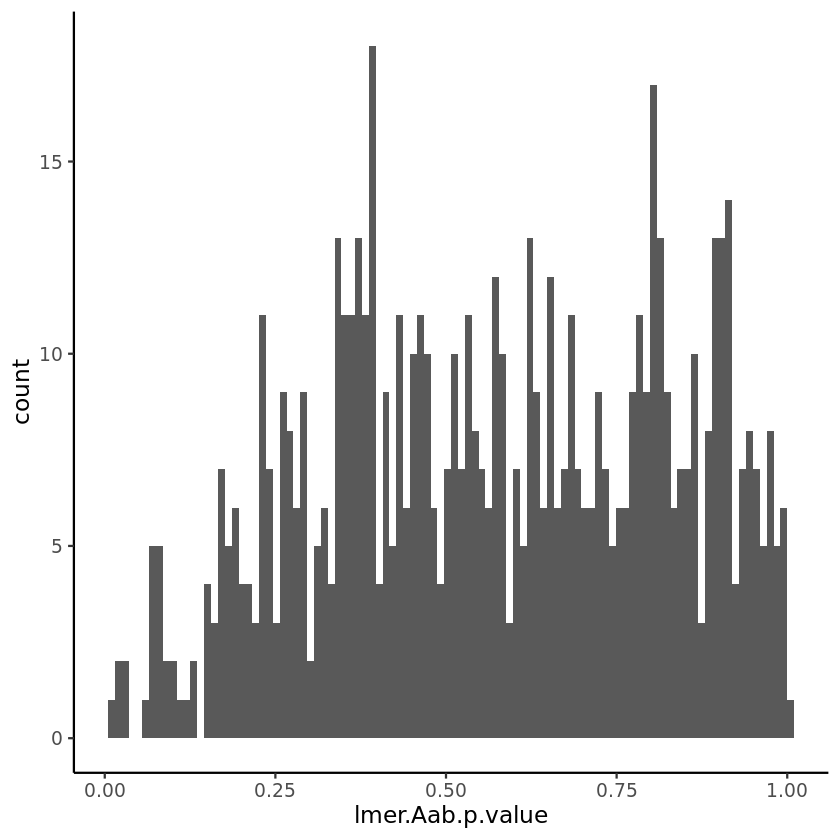

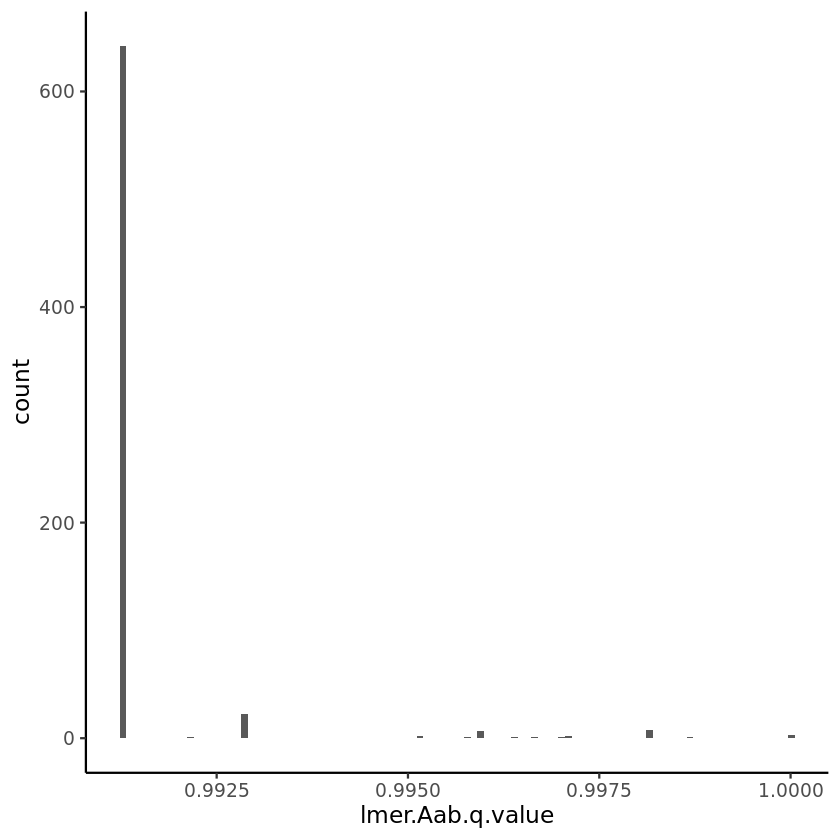

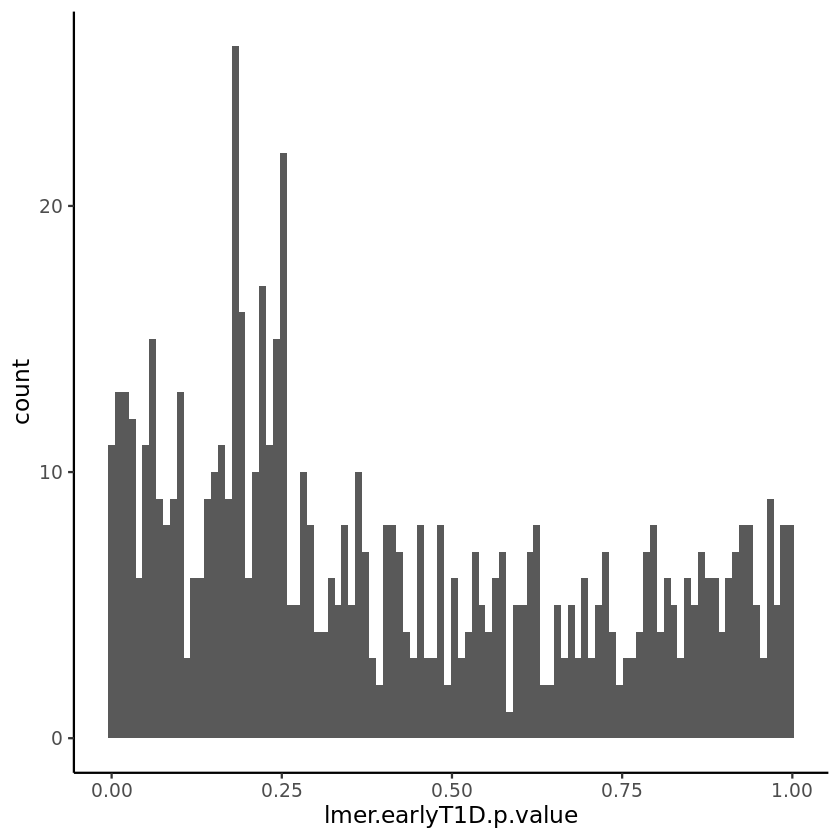

,Motif,lmer.Aab.Effect,lmer.Aab.p.value,lmer.Aab.t.stat,lmer.earlyT1D.Effect,lmer.earlyT1D.p.value,lmer.earlyT1D.t.stat,lmer.Aab.q.value,lmer.earlyT1D.q.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0770.1_HSF2,MA0770.1_HSF2,-0.022611553,0.4747221,-0.7149604,0.2536077,6.435965e-06,4.524359,0.9912625,0.004291442
MA0687.1_SPIC,MA0687.1_SPIC,0.030225714,0.4107569,0.8227455,0.2751024,2.503599e-05,4.224996,0.9912625,0.008346881
MA0790.1_POU4F1,MA0790.1_POU4F1,0.035683533,0.5267387,0.6472575,-0.3691143,6.892670e-04,-4.020278,0.9912625,0.153198921
MA1970.1_TRPS1,MA1970.1_TRPS1,-0.034121227,0.4758368,-0.7348981,0.2960618,1.657413e-03,3.743558,0.9912625,0.230529070
MA0486.2_HSF1,MA0486.2_HSF1,0.016833732,0.6546348,0.4643133,0.2470655,2.226507e-03,3.939469,0.9912625,0.230529070
MA1731.1_ZNF768,MA1731.1_ZNF768,0.007854668,0.8167233,0.2374018,0.2087358,2.384855e-03,3.628181,0.9912625,0.230529070


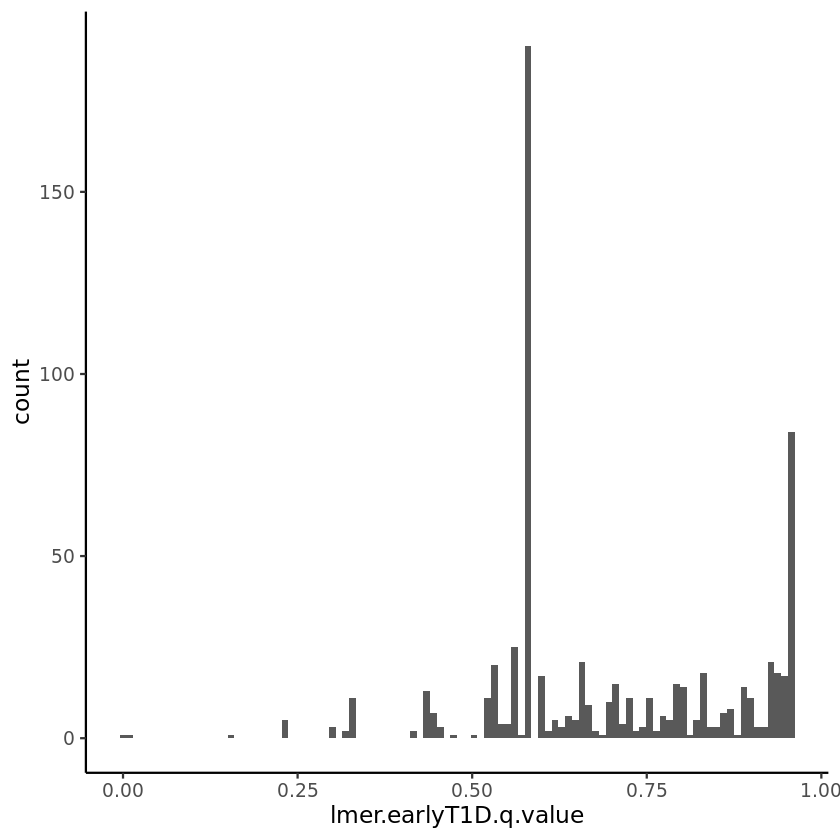

In [9]:
# This runs our linear model! 

#Prep inputs
new_df <- barcode_motif_matrix_bc_joined
new_df$samples <- as.character(new_df$samples) # Sample names were numbers; the formula tried to treat this as a continuous variable
new_df$Sex <- as.numeric(as.factor(new_df$Sex)) # Binarize, skip if not in model
new_df <- filter(new_df, samples %in% names(which(table(barcode_motif_matrix$samples)  > 10))) # Filter for sufficient barcodes

# Repeat for conditions as needed. You need one dummy variable for each contrast (ie 1 for ND vs Aab, etc., totaling to 1 less than the # of conditions)
# Encoded Variables (dummy variables) need to be created that represent the comparison of each condition to control
# They are weighted so each column of dummy variable sums to 0. Why? Because people who know more said so...
new_df$Aab_weighted_barcode <- as.integer(new_df$groups=='Aab')
new_df$Aab_weighted_barcode[new_df$groups=='ND'] <- -(sum(new_df$groups=='Aab')/sum(new_df$groups=='ND'))

new_df$earlyT1D_weighted_barcode <- as.integer(new_df$groups=='earlyT1D')
new_df$earlyT1D_weighted_barcode[new_df$groups=='ND'] <- -(sum(new_df$groups=='earlyT1D')/sum(new_df$groups=='ND'))

#Ehhh not vital but helped with plotting at one point
#new_df$groups <- factor(new_df$groups, levels=c('ND','Aab','earlyT1D'))

# I rearranged the input so all the motifs are at the end of the data frame so I can iterate from the first
# to the last smoothly in the testing process.
new_df <- arrange(new_df, groups) %>%
  select(Aab_weighted_barcode, earlyT1D_weighted_barcode, groups, samples, 
         Age, Sex, BMI, TSS.enrichment, FRIP, nCount_ATAC, nFeature_ATAC, everything())

# Create a data frame to hold output. Number of rows is # of motifs, number of columns is 1 + (3 * # dummy variables)
lmer_results = data.frame(matrix(nrow=nrow(ct_devscores), ncol = 7))
rownames(lmer_results)= colnames(as.data.frame(t(ct_devscores)))
# Create columns to save outputs. I took the effect estimate, the p value, and the t value (which is the test statistic)
colnames(lmer_results) <- c('Motif', 'lmer.Aab.Effect', 'lmer.Aab.p.value', 'lmer.Aab.t.stat',
                                          'lmer.earlyT1D.Effect', 'lmer.earlyT1D.p.value', 'lmer.earlyT1D.t.stat')

for(i in (ncol(new_df) - nrow(devscores) + 1):ncol(new_df)){
#for(i in 17:23){
    # Get the motif name
    column <- names(new_df[i])

    # Run the model. Adjust with covariates, it is a good idea to scale and center them.
    # The random effect for sample is encoded as (1|sample), which indicates it allows the 
    # intercept but not the slope to vary
    mod6=lmerTest::lmer(new_df[,i] ~ Aab_weighted_barcode + earlyT1D_weighted_barcode + scale(FRIP) + scale(nCount_ATAC) + (1|samples), data = new_df)

    # Save outputs
    lmer_results[column,'Motif'] <- column

    # Check that you are getting the right rows of the model
    lmer_results[column,'lmer.Aab.Effect'] <- summary(mod6)[['coefficients']][2,1]
    lmer_results[column,'lmer.Aab.p.value'] <- summary(mod6)[['coefficients']][2,5]
    lmer_results[column,'lmer.Aab.t.stat'] <- summary(mod6)[['coefficients']][2,4]

    lmer_results[column,'lmer.earlyT1D.Effect'] <- summary(mod6)[['coefficients']][3,1]
    lmer_results[column,'lmer.earlyT1D.p.value'] <- summary(mod6)[['coefficients']][3,5]
    lmer_results[column,'lmer.earlyT1D.t.stat'] <- summary(mod6)[['coefficients']][3,4]
}

# FDR calculations
lmer_results <- arrange(lmer_results, lmer.Aab.p.value)
lmer_results$lmer.Aab.q.value <- qvalue(lmer_results$lmer.Aab.p.value)$qvalues

lmer_results <- arrange(lmer_results, lmer.earlyT1D.p.value)
lmer_results$lmer.earlyT1D.q.value <- qvalue(lmer_results$lmer.earlyT1D.p.value)$qvalues

# p-value and q-value histograms

ggplot(lmer_results, aes(x=lmer.Aab.p.value)) + geom_histogram(bins=100) +
    theme_classic(base_size=14)
ggplot(lmer_results, aes(x=lmer.Aab.q.value)) + geom_histogram(bins=100) +
    theme_classic(base_size=14)
ggplot(lmer_results, aes(x=lmer.earlyT1D.p.value)) + geom_histogram(bins=100) +
    theme_classic(base_size=14)
ggplot(lmer_results, aes(x=lmer.earlyT1D.q.value)) + geom_histogram(bins=100) +
    theme_classic(base_size=14)

head(lmer_results)

In [10]:
# Write out test results
write.table(lmer_results, '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240209_WE_Beta_Disease_mixed_model_outs.tsv',
           sep='\t',row.names=F, col.names=T, quote=F)

In [11]:
# Write out test data
write.table(new_df, '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240126_WE_Beta_Disease_mixed_model_data.tsv',
           sep='\t',row.names=F, col.names=T, quote=F)

# Graphing - TO DO  

##### Ideas:
-Volcano plot (1 cell type, ND vs condition)  
-Heatmap (1 cell type, all conditions, sig marked by *)  
-Sample level boxplots (1 box per condition)  
-Barcode level boxplots (1 box per sample, grouped by condition)  

In [12]:
#lmer_results <- read.table('/nfs/lab/welison/multiome/chromvar/230522_ChromVar_Outputs/240126_WE_Beta_Disease_mixed_model_outs.tsv',
#           sep='\t', header=T)
#
dim(lmer_results)
head(lmer_results)

[1] 692   9

,Motif,lmer.Aab.Effect,lmer.Aab.p.value,lmer.Aab.t.stat,lmer.earlyT1D.Effect,lmer.earlyT1D.p.value,lmer.earlyT1D.t.stat,lmer.Aab.q.value,lmer.earlyT1D.q.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0770.1_HSF2,MA0770.1_HSF2,-0.022611553,0.4747221,-0.7149604,0.2536077,6.435965e-06,4.524359,0.9912625,0.004291442
MA0687.1_SPIC,MA0687.1_SPIC,0.030225714,0.4107569,0.8227455,0.2751024,2.503599e-05,4.224996,0.9912625,0.008346881
MA0790.1_POU4F1,MA0790.1_POU4F1,0.035683533,0.5267387,0.6472575,-0.3691143,6.892670e-04,-4.020278,0.9912625,0.153198921
MA1970.1_TRPS1,MA1970.1_TRPS1,-0.034121227,0.4758368,-0.7348981,0.2960618,1.657413e-03,3.743558,0.9912625,0.230529070
MA0486.2_HSF1,MA0486.2_HSF1,0.016833732,0.6546348,0.4643133,0.2470655,2.226507e-03,3.939469,0.9912625,0.230529070
MA1731.1_ZNF768,MA1731.1_ZNF768,0.007854668,0.8167233,0.2374018,0.2087358,2.384855e-03,3.628181,0.9912625,0.230529070


In [13]:
#new_df <- read.table('/nfs/lab/welison/multiome/chromvar/230522_ChromVar_Outputs/240126_WE_Beta_Disease_mixed_model_data.tsv',
#           sep='\t', header=T)
#
dim(new_df)
head(new_df)

[1] 1888  704

,Aab_weighted_barcode,earlyT1D_weighted_barcode,groups,samples,Age,Sex,BMI,TSS.enrichment,FRIP,nCount_ATAC,⋯,MA1511.2_KLF10,MA1525.2_NFATC4,MA1532.2_NR1D2,MA1547.2_PITX2,MA1563.2_SOX18,MA1566.2_TBX3,MA1601.2_ZNF75D,MA1630.2_ZNF281,MA1633.2_BACH1,MA0597.2_THAP1
,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0,Aab,6197,22,2,28.2,3.344519,0.4275936,13243,⋯,-0.4549613,-0.09568275,-1.40634101,1.67602830,-0.55786578,0.63024378,-0.055343233,-0.68955207,-4.496914,-0.1772622
2,1,0,Aab,6197,22,2,28.2,2.950673,0.4517270,7605,⋯,-0.8138323,1.80509039,0.67105669,0.95170286,-0.69882626,-0.88314744,0.271116727,0.12391807,-1.844071,-1.0285388
3,1,0,Aab,6197,22,2,28.2,2.837341,0.4117878,11008,⋯,-1.0576486,2.45638133,-0.09208358,0.34811037,-1.06690812,1.58829190,-0.964827950,0.87797276,-5.156085,0.2317332
4,1,0,Aab,6197,22,2,28.2,3.630332,0.4456573,10042,⋯,-0.7351053,1.12849303,0.17059731,0.19294903,0.12964949,0.66533173,-1.384100307,-0.68850602,-5.049680,-1.3420260
5,1,0,Aab,6197,22,2,28.2,2.585120,0.3807368,12225,⋯,-0.8377574,0.24376074,-0.08141930,1.24435591,-0.09987625,-1.89854109,-0.006865639,-0.55994149,-3.960869,-1.7775846
6,1,0,Aab,6197,22,2,28.2,3.351536,0.3626189,7692,⋯,-0.2234593,0.92021230,-0.02996020,-0.04219776,-0.88861521,-0.08103682,0.218513686,0.09126462,-1.175885,-0.7424363


### Volcano

In [14]:
# Average motif by sample
sample_data <- select(new_df, -Aab_weighted_barcode, -earlyT1D_weighted_barcode, -Age, -Sex, -BMI,
       -TSS.enrichment, -FRIP, -nCount_ATAC, -nFeature_ATAC, -bc) %>%
    group_by(groups, samples) %>%
    summarise_all(mean, na.rm=T)

dim(sample_data)
head(sample_data)

[1]  19 694

groups,samples,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,⋯,MA1511.2_KLF10,MA1525.2_NFATC4,MA1532.2_NR1D2,MA1547.2_PITX2,MA1563.2_SOX18,MA1566.2_TBX3,MA1601.2_ZNF75D,MA1630.2_ZNF281,MA1633.2_BACH1,MA0597.2_THAP1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Aab,6197,2.857429,2.860531,-0.9811797,0.39007216,-0.26512313,1.757859,0.7917269,-0.2703282090,⋯,-0.6696456,1.027379,-0.41786663,0.5450014,-0.4744134,-0.12747310,-0.7268262,-0.22993226,-3.47392000,-0.31415599
Aab,6267,1.860634,1.903372,-0.8177361,0.86725028,0.04063517,1.459343,0.3639584,0.0006624538,⋯,-0.4314229,1.513212,-0.09334161,0.3764946,-0.6612990,0.40020625,-0.5936006,-0.05057467,0.09774571,0.12242960
Aab,6424,2.484501,2.390254,-0.4141324,0.04704163,-0.38651029,2.133007,0.4808262,-0.1870447233,⋯,-0.8010450,1.349239,-0.35767515,0.6037999,-0.3738545,0.05808414,-0.5813791,-0.59525931,-1.21851120,-0.21931572
Aab,6429,2.237114,2.278920,-0.8383157,0.29009326,-0.12217415,1.417371,1.0484290,-0.1363430361,⋯,-0.8722497,1.424488,-0.37682011,0.3981130,-0.5108478,0.01219261,-0.5460460,-0.69083363,-2.81044507,-0.09660275
Aab,6450,2.115093,1.987055,-0.8780517,1.17216206,-0.03567387,1.307238,0.4696527,-0.0769514091,⋯,-0.5587101,2.075482,-0.05366765,0.3765272,-0.2963673,-0.13200643,-0.5715724,-0.21078352,0.08741107,0.14406987
Aab,6505,1.902494,2.186824,-0.5803057,0.07523361,-0.25680290,1.276026,0.8166820,-0.2661216285,⋯,-0.6883667,1.227863,-0.19106434,0.1579877,-0.0366350,0.12976416,-0.3937469,-0.51164437,-1.23870739,-0.12626308


In [15]:
# Average motif by disease state
group_data <- select(sample_data, -samples) %>%
    group_by(groups) %>%
    summarise_all(mean, na.rm=T)

dim(group_data)
head(group_data)

[1]   3 693

groups,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,MA0072.1_RORA,⋯,MA1511.2_KLF10,MA1525.2_NFATC4,MA1532.2_NR1D2,MA1547.2_PITX2,MA1563.2_SOX18,MA1566.2_TBX3,MA1601.2_ZNF75D,MA1630.2_ZNF281,MA1633.2_BACH1,MA0597.2_THAP1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Aab,2.242011,2.264140,-0.6843334,0.4408855,-0.16395025,1.573346,0.6442481,-0.1753196,0.2204071,⋯,-0.6802063,1.452999,-0.2706122,0.4095547,-0.3681477,0.05174608,-0.5687519,-0.3899620,-1.650520,-0.10498904
ND,2.278086,2.337145,-0.6664534,0.3218717,-0.17560012,1.677918,0.7707289,-0.2954247,0.1767948,⋯,-0.6282202,1.656933,-0.2873285,0.3617666,-0.3273597,-0.04318980,-0.5243711,-0.3513095,-2.292179,-0.18996940
earlyT1D,1.945234,1.728518,-0.4945870,0.5210940,-0.07829518,1.470386,0.5378442,-0.2214101,0.2312356,⋯,-0.6764868,1.510252,-0.3293363,0.1998923,-0.3529177,-0.14292372,-0.6717869,-0.4225353,-1.982436,0.02197451


In [16]:
# Transpose counts and join to lmer outputs
counts_t <- tibble::column_to_rownames(group_data, var='groups') %>%
    t() %>%
    data.frame()

volcano_data <- cbind(lmer_results, counts_t[rownames(lmer_results),])

dim(volcano_data)
head(volcano_data)

[1] 692  12

,Motif,lmer.Aab.Effect,lmer.Aab.p.value,lmer.Aab.t.stat,lmer.earlyT1D.Effect,lmer.earlyT1D.p.value,lmer.earlyT1D.t.stat,lmer.Aab.q.value,lmer.earlyT1D.q.value,Aab,ND,earlyT1D
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0770.1_HSF2,MA0770.1_HSF2,-0.022611553,0.4747221,-0.7149604,0.2536077,6.435965e-06,4.524359,0.9912625,0.004291442,-0.9313501,-0.9468423,-0.68555016
MA0687.1_SPIC,MA0687.1_SPIC,0.030225714,0.4107569,0.8227455,0.2751024,2.503599e-05,4.224996,0.9912625,0.008346881,-2.9445575,-3.0740993,-2.65133978
MA0790.1_POU4F1,MA0790.1_POU4F1,0.035683533,0.5267387,0.6472575,-0.3691143,6.892670e-04,-4.020278,0.9912625,0.153198921,1.3269995,1.3821701,0.93499204
MA1970.1_TRPS1,MA1970.1_TRPS1,-0.034121227,0.4758368,-0.7348981,0.2960618,1.657413e-03,3.743558,0.9912625,0.230529070,-2.0467880,-2.1090819,-1.71205081
MA0486.2_HSF1,MA0486.2_HSF1,0.016833732,0.6546348,0.4643133,0.2470655,2.226507e-03,3.939469,0.9912625,0.230529070,-0.9340239,-1.0165672,-0.75230095
MA1731.1_ZNF768,MA1731.1_ZNF768,0.007854668,0.8167233,0.2374018,0.2087358,2.384855e-03,3.628181,0.9912625,0.230529070,-0.0946025,-0.1930561,0.08081474


[1] "Aab"      "earlyT1D"

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”


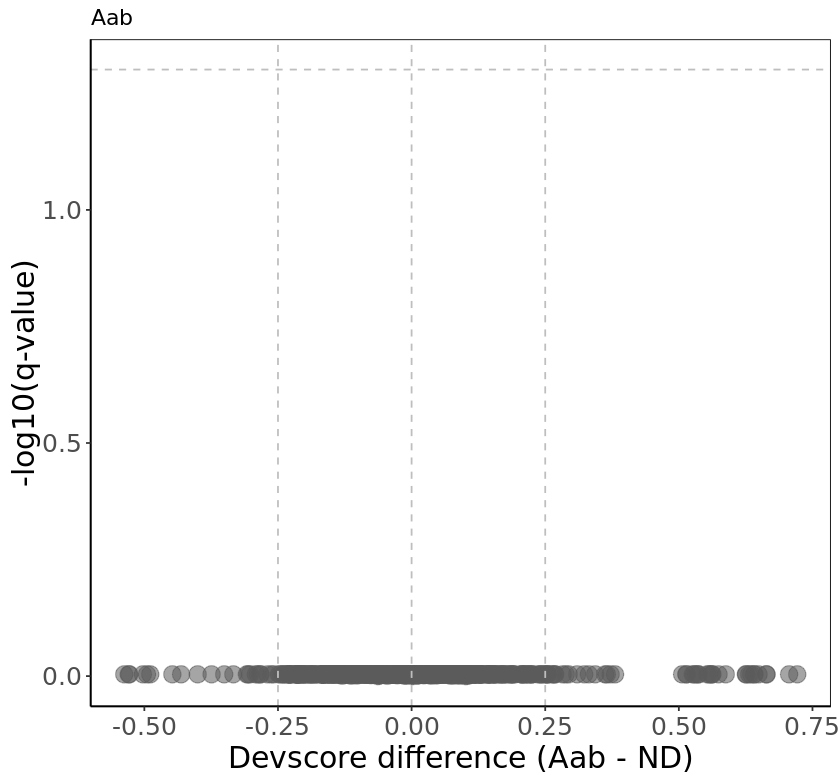

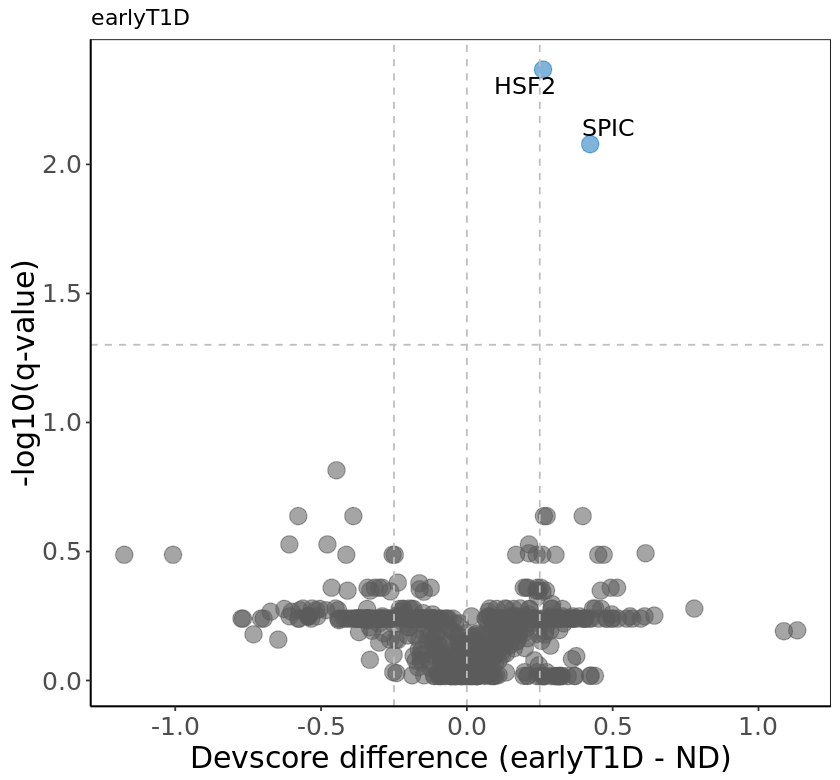

In [17]:
# Make and save volcano plots

# Select conditions to compare
tested <- colnames(counts_t)[colnames(counts_t) != 'ND']
tested

# Select cutoffs for plot
delta_cutoff <- 0.25
q_cutoff <- 0.05

for (case in tested) {
    #Calculate difference in accessibility
    volcano_data[[paste0("diff.", case)]] <- volcano_data[[case]] - volcano_data$ND
    
    #Add colors
    volcano_data[[paste0("color.", case)]] <- ifelse(abs(volcano_data[[paste0("diff.", case)]]) <= delta_cutoff, 'grey', #doesn't pass delta cutoff
                         ifelse(volcano_data[[paste0("lmer.", case, '.q.value')]] >= q_cutoff, 'grey', #doesn't pass padj cutoff
                                ifelse(volcano_data[[paste0("diff.", case)]] < 0, 'red', #negative diff
                                       'blue'))) #positive diff 
    #Add labels for significant ones
    volcano_data[[paste0("label.", case)]] <- NA
    to_label <- subset(volcano_data, abs(volcano_data[[paste0("diff.", case)]]) > delta_cutoff & 
                       volcano_data[[paste0("lmer.", case,'.q.value')]] < q_cutoff)
    volcano_data[row.names(to_label),][[paste0("label.", case)]] <- str_split_fixed(row.names(to_label), '_', 2)[,2]
    
    # Make Volcano plot
    options(repr.plot.width=7, repr.plot.height=6.5)
    theme_set(theme_classic())
    p1 <- ggplot(data=volcano_data, aes(x=.data[[paste0("diff.", case)]], y=-log10(.data[[paste0("lmer.", case,'.q.value')]]), 
                                        col=.data[[paste0("color.", case)]], label=.data[[paste0("label.", case)]])) +
            geom_point(aes(alpha=0.7, size=1)) + 
            scale_color_manual(values=c('grey'='#5C5C5C', 'blue'='#1976BD', 'red'='#BD1919')) +
            geom_vline(xintercept=c(-delta_cutoff, 0, delta_cutoff), col="grey", linetype='dashed') + 
            geom_hline(yintercept=-log10(q_cutoff), col="grey", linetype='dashed') + 
            ggrepel::geom_text_repel(col=c("black"), size=5) +
            xlab(sprintf('Devscore difference (%s - %s)',case, 'ND')) + 
            ylab('-log10(q-value)') + ggtitle(case) + 
            theme(legend.position = "none", panel.border=element_rect(colour = 'black', fill=NA), 
                  axis.title.x=element_text(size=18, vjust=0.5), axis.text.x=element_text(size=15, vjust=0.5),
                  axis.title.y=element_text(size=18, vjust=0.5), axis.text.y=element_text(size=15, vjust=0.5)) 
    
    print(p1)
    
    #Save the results
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                   "Beta","_lmer_volcano_ND_vs_",case,".pdf"), width=7, height=6.5)
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                   "Beta","_lmer_volcano_ND_vs_",case,".png"), width=7, height=6.5)
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                   "Beta","_lmer_volcano_ND_vs_",case,".svg"), width=7, height=6.5)
}

#Save the data so plotting is easier down the road
write.table(volcano_data, paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                   "Beta","_lmer_volcano_data.tsv"),
           col.names=T, row.names=T, quote=F, sep='\t')

### Boxplots - Sample Pseudobulk

In [18]:
# Load in data and order disease states
boxplot_data <- sample_data
boxplot_data$groups[boxplot_data$groups=='earlyT1D'] <- 'Early_T1D'
boxplot_data$groups <- factor(boxplot_data$groups, levels=c('ND','Aab','Early_T1D'))

# Create output directory
dir.create(paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",
                  "Beta"))

#for (i in 3:4) {
for (i in 3:ncol(boxplot_data)) {
    motif <- colnames(boxplot_data)[i]
    print(motif)
    
    # Make boxplot
    p1 <- ggplot(boxplot_data, aes(x=groups, y=.data[[motif]], fill=groups)) + geom_boxplot(outlier.shape=NA) + geom_jitter(width=.2) +
            xlab("Disease State") + 
            ylab('Motif Accessibility') + ggtitle(motif) +
            theme(legend.position = "none", panel.border=element_rect(colour = 'black', fill=NA), 
                  axis.title.x=element_text(size=18, vjust=0.5), axis.text.x=element_text(size=15, vjust=0.5),
                  axis.title.y=element_text(size=18, vjust=0.5), axis.text.y=element_text(size=15, vjust=0.5)) 
    #print(p1)
    
    #Save boxplots
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "/240214_WE_","Beta","_",motif,"_sample_boxplot.pdf"), width=7, height=6.5)
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "/240214_WE_","Beta","_",motif,"_sample_boxplot.png"), width=7, height=6.5)
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "/240214_WE_","Beta","_",motif,"_sample_boxplot.svg"), width=7, height=6.5)
}

#Save data
write.table(boxplot_data, paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "_sample_boxplot_data.tsv"),
           col.names=T, row.names=T, quote=F, sep='\t')

Warning message in dir.create(paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/", :
“'/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/Beta' already exists”


[1] "MA0030.1_FOXF2"
[1] "MA0031.1_FOXD1"
[1] "MA0051.1_IRF2"
[1] "MA0059.1_MAX::MYC"
[1] "MA0066.1_PPARG"
[1] "MA0069.1_PAX6"
[1] "MA0070.1_PBX1"
[1] "MA0071.1_RORA"
[1] "MA0072.1_RORA"
[1] "MA0073.1_RREB1"
[1] "MA0074.1_RXRA::VDR"
[1] "MA0077.1_SOX9"
[1] "MA0084.1_SRY"
[1] "MA0091.1_TAL1::TCF3"
[1] "MA0101.1_REL"
[1] "MA0107.1_RELA"
[1] "MA0115.1_NR1H2::RXRA"
[1] "MA0119.1_NFIC::TLX1"
[1] "MA0130.1_ZNF354C"
[1] "MA0139.1_CTCF"
[1] "MA0149.1_EWSR1-FLI1"
[1] "MA0138.2_REST"
[1] "MA0155.1_INSM1"
[1] "MA0159.1_RARA::RXRA"
[1] "MA0163.1_PLAG1"
[1] "MA0259.1_ARNT::HIF1A"
[1] "MA0468.1_DUX4"
[1] "MA0476.1_FOS"
[1] "MA0478.1_FOSL2"
[1] "MA0479.1_FOXH1"
[1] "MA0488.1_JUN"
[1] "MA0492.1_JUND"
[1] "MA0497.1_MEF2C"
[1] "MA0501.1_MAF::NFE2"
[1] "MA0504.1_NR2C2"
[1] "MA0517.1_STAT1::STAT2"
[1] "MA0523.1_TCF7L2"
[1] "MA0527.1_ZBTB33"
[1] "MA0076.2_ELK4"
[1] "MA0258.2_ESR2"
[1] "MA0137.3_STAT1"
[1] "MA0144.2_STAT3"
[1] "MA0140.2_GATA1::TAL1"
[1] "MA0593.1_FOXP2"
[1] "MA0595.1_SREBF1"
[1] "MA0596.1_S

[1] "MA1568.1_TCF21"
[1] "MA1569.1_TFAP2E"
[1] "MA1570.1_TFAP4"
[1] "MA1571.1_TGIF2LX"
[1] "MA1572.1_TGIF2LY"
[1] "MA1574.1_THRB"
[1] "MA1575.1_THRB"
[1] "MA1576.1_THRB"
[1] "MA1577.1_TLX2"
[1] "MA1578.1_VEZF1"
[1] "MA1579.1_ZBTB26"
[1] "MA1580.1_ZBTB32"
[1] "MA1581.1_ZBTB6"
[1] "MA1583.1_ZFP57"
[1] "MA1584.1_ZIC5"
[1] "MA1585.1_ZKSCAN1"
[1] "MA1587.1_ZNF135"
[1] "MA1588.1_ZNF136"
[1] "MA1589.1_ZNF140"
[1] "MA1592.1_ZNF274"
[1] "MA1593.1_ZNF317"
[1] "MA1594.1_ZNF382"
[1] "MA1596.1_ZNF460"
[1] "MA1597.1_ZNF528"
[1] "MA1599.1_ZNF682"
[1] "MA1600.1_ZNF684"
[1] "MA1602.1_ZSCAN29"
[1] "MA1100.2_ASCL1"
[1] "MA0605.2_ATF3"
[1] "MA0462.2_BATF::JUN"
[1] "MA0463.2_BCL6"
[1] "MA0864.2_E2F2"
[1] "MA0469.3_E2F3"
[1] "MA0470.2_E2F4"
[1] "MA0612.2_EMX1"
[1] "MA0766.2_GATA5"
[1] "MA0038.2_GFI1"
[1] "MA0893.2_GSX2"
[1] "MA1099.2_HES1"
[1] "MA0616.2_HES2"
[1] "MA0900.2_HOXA2"
[1] "MA0158.2_HOXA5"
[1] "MA0594.2_HOXA9"
[1] "MA0902.2_HOXB2"
[1] "MA0904.2_HOXB5"
[1] "MA0485.2_HOXC9"
[1] "MA0912.2_HOXD3"
[1]

### Boxplots - Barcode By Sample

In [19]:
#Order disease states
barcode_boxplot_data <- new_df
barcode_boxplot_data$groups[barcode_boxplot_data$groups=='earlyT1D'] <- 'Early_T1D'
barcode_boxplot_data$groups <- factor(barcode_boxplot_data$groups, levels=c('ND','Aab','Early_T1D'))

#Create output directory
dir.create(paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",
                  "Beta"))

#Create color schema
samples_color <- select(barcode_boxplot_data, groups, samples) %>%
    arrange(groups, samples) 

samples_color <- samples_color[!duplicated(samples_color),]

reds <- brewer.pal(n = (sum(samples_color$groups == 'ND') + 1), name = 'Reds')
greens <- brewer.pal(n = (sum(samples_color$groups == 'Aab') + 1), name = 'Greens')
blues <- brewer.pal(n = (sum(samples_color$groups == 'Early_T1D') + 1), name = 'Blues')

custom_pallette <- c(reds[2:length(reds)], greens[2:length(greens)], blues[2:length(blues)])

names(custom_pallette) <- samples_color$samples


#for (i in (ncol(barcode_boxplot_data) - 691):(ncol(barcode_boxplot_data) - 690)) {
for (i in (ncol(barcode_boxplot_data) - 691):ncol(barcode_boxplot_data)) {
    motif <- colnames(barcode_boxplot_data)[i]
    print(motif)
    
    #Make boxplot
    p1 <- ggplot(barcode_boxplot_data, aes(x=groups, y=.data[[motif]], fill=samples)) + geom_boxplot() +
            xlab("Disease State") + 
            ylab('Motif Accessibility') + ggtitle(motif) +
            scale_fill_manual(values=custom_pallette) +
            theme(panel.border=element_rect(colour = 'black', fill=NA), 
                  axis.title.x=element_text(size=18, vjust=0.5), axis.text.x=element_text(size=15, vjust=0.5),
                  axis.title.y=element_text(size=18, vjust=0.5), axis.text.y=element_text(size=15, vjust=0.5)) 
    #print(p1)
    
    #Save the boxplot
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "/240214_WE_","Beta","_",motif,"_barcode_boxplot.pdf"), width=7, height=6.5)
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "/240214_WE_","Beta","_",motif,"_barcode_boxplot.png"), width=7, height=6.5)
    ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "/240214_WE_","Beta","_",motif,"_barcode_boxplot.svg"), width=7, height=6.5)
}

#Save data
write.table(barcode_boxplot_data, paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/","Beta",
                                    "_barcode_boxplot_data.tsv"),
           col.names=T, row.names=T, quote=F, sep='\t')

Warning message in dir.create(paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/", :
“'/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/Beta' already exists”


[1] "MA0030.1_FOXF2"
[1] "MA0031.1_FOXD1"
[1] "MA0051.1_IRF2"
[1] "MA0059.1_MAX::MYC"
[1] "MA0066.1_PPARG"
[1] "MA0069.1_PAX6"
[1] "MA0070.1_PBX1"
[1] "MA0071.1_RORA"
[1] "MA0072.1_RORA"
[1] "MA0073.1_RREB1"
[1] "MA0074.1_RXRA::VDR"
[1] "MA0077.1_SOX9"
[1] "MA0084.1_SRY"
[1] "MA0091.1_TAL1::TCF3"
[1] "MA0101.1_REL"
[1] "MA0107.1_RELA"
[1] "MA0115.1_NR1H2::RXRA"
[1] "MA0119.1_NFIC::TLX1"
[1] "MA0130.1_ZNF354C"
[1] "MA0139.1_CTCF"
[1] "MA0149.1_EWSR1-FLI1"
[1] "MA0138.2_REST"
[1] "MA0155.1_INSM1"
[1] "MA0159.1_RARA::RXRA"
[1] "MA0163.1_PLAG1"
[1] "MA0259.1_ARNT::HIF1A"
[1] "MA0468.1_DUX4"
[1] "MA0476.1_FOS"
[1] "MA0478.1_FOSL2"
[1] "MA0479.1_FOXH1"
[1] "MA0488.1_JUN"
[1] "MA0492.1_JUND"
[1] "MA0497.1_MEF2C"
[1] "MA0501.1_MAF::NFE2"
[1] "MA0504.1_NR2C2"
[1] "MA0517.1_STAT1::STAT2"
[1] "MA0523.1_TCF7L2"
[1] "MA0527.1_ZBTB33"
[1] "MA0076.2_ELK4"
[1] "MA0258.2_ESR2"
[1] "MA0137.3_STAT1"
[1] "MA0144.2_STAT3"
[1] "MA0140.2_GATA1::TAL1"
[1] "MA0593.1_FOXP2"
[1] "MA0595.1_SREBF1"
[1] "MA0596.1_S

[1] "MA1568.1_TCF21"
[1] "MA1569.1_TFAP2E"
[1] "MA1570.1_TFAP4"
[1] "MA1571.1_TGIF2LX"
[1] "MA1572.1_TGIF2LY"
[1] "MA1574.1_THRB"
[1] "MA1575.1_THRB"
[1] "MA1576.1_THRB"
[1] "MA1577.1_TLX2"
[1] "MA1578.1_VEZF1"
[1] "MA1579.1_ZBTB26"
[1] "MA1580.1_ZBTB32"
[1] "MA1581.1_ZBTB6"
[1] "MA1583.1_ZFP57"
[1] "MA1584.1_ZIC5"
[1] "MA1585.1_ZKSCAN1"
[1] "MA1587.1_ZNF135"
[1] "MA1588.1_ZNF136"
[1] "MA1589.1_ZNF140"
[1] "MA1592.1_ZNF274"
[1] "MA1593.1_ZNF317"
[1] "MA1594.1_ZNF382"
[1] "MA1596.1_ZNF460"
[1] "MA1597.1_ZNF528"
[1] "MA1599.1_ZNF682"
[1] "MA1600.1_ZNF684"
[1] "MA1602.1_ZSCAN29"
[1] "MA1100.2_ASCL1"
[1] "MA0605.2_ATF3"
[1] "MA0462.2_BATF::JUN"
[1] "MA0463.2_BCL6"
[1] "MA0864.2_E2F2"
[1] "MA0469.3_E2F3"
[1] "MA0470.2_E2F4"
[1] "MA0612.2_EMX1"
[1] "MA0766.2_GATA5"
[1] "MA0038.2_GFI1"
[1] "MA0893.2_GSX2"
[1] "MA1099.2_HES1"
[1] "MA0616.2_HES2"
[1] "MA0900.2_HOXA2"
[1] "MA0158.2_HOXA5"
[1] "MA0594.2_HOXA9"
[1] "MA0902.2_HOXB2"
[1] "MA0904.2_HOXB5"
[1] "MA0485.2_HOXC9"
[1] "MA0912.2_HOXD3"
[1]